# Satellite Telemetry Anomaly Detection - Exploratory Data Analysis
This notebook contains the preliminary data loading, verification, and exploratory analysis of the satellite telemetry dataset

## 1. Environment Setup
Libraries import and data paths definition.

In [31]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
DATASET_PATH  = "../data/dataset.csv"
SEGMENTS_PATH = "../data/segments.csv"

## 2. Global Features Dataset Exploration
Data ingestion and structural verification.

In [13]:
if os.path.exists(DATASET_PATH):
    df_dataset = pd.read_csv(DATASET_PATH)
    print("=== DATASET (Global Features) ===")
    print(f"Status: Loaded successfully")
    print(f"Observations (Rows): {df_dataset.shape[0]}")
    print(f"Features (Columns):  {df_dataset.shape[1]}\n")
    print("--- Detailed Summary ---")
    df_dataset.info()
else:
    print(f"Error: Target file not found at {DATASET_PATH}")

=== DATASET (Global Features) ===
Status: Loaded successfully
Observations (Rows): 2123
Features (Columns):  23

--- Detailed Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 2123 entries, 0 to 2122
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   segment           2123 non-null   int64  
 1   anomaly           2123 non-null   int64  
 2   train             2123 non-null   int64  
 3   channel           2123 non-null   str    
 4   sampling          2123 non-null   int64  
 5   duration          2123 non-null   int64  
 6   len               2123 non-null   int64  
 7   mean              2123 non-null   float64
 8   var               2123 non-null   float64
 9   std               2123 non-null   float64
 10  kurtosis          2123 non-null   float64
 11  skew              2123 non-null   float64
 12  n_peaks           2123 non-null   int64  
 13  smooth10_n_peaks  2123 non-null   int64  
 14  smooth20_

In [ ]:
if os.path.exists(SEGMENTS_PATH):
    df_segments = pd.read_csv(SEGMENTS_PATH)
    print("=== SEGMENTS (Raw Time-Series) ===")
    print(f"Status: Loaded successfully")
    print(f"Temporal Points (Rows): {df_segments.shape[0]}")
    print(f"Variables (Columns):    {df_segments.shape[1]}\n")
    print("--- First 5 Rows ---")
    display(df_segments.head()) 
else:
    print(f"Error: Target file not found at {SEGMENTS_PATH}")

=== SEGMENTS (Raw Time-Series) ===
Status: Loaded successfully
Temporal Points (Rows): 303493
Variables (Columns):    8

--- First 5 Rows ---


,channel,timestamp,value,label,sampling,anomaly,segment,train
0,CADC0872,2022-06-01T23:42:54.000Z,-0.000021,anomaly,1,1,1,1
1,CADC0872,2022-06-01T23:42:55.000Z,-0.000021,anomaly,1,1,1,1
2,CADC0872,2022-06-01T23:42:56.000Z,-0.000021,anomaly,1,1,1,1
3,CADC0872,2022-06-01T23:42:57.000Z,-0.000021,anomaly,1,1,1,1
4,CADC0872,2022-06-01T23:42:58.000Z,-0.000021,anomaly,1,1,1,1


## 3. Dataset Properties
Statistical and visual profiling of core table attributes and semantic partitions.

In [37]:
def compute_column_statistics(df, column, title):
    if column not in df.columns:
        print(f"Error: Required column '{column}' not found.")
        return
    print(f"=== {title.upper()} ANALYSIS ===")
    print(f"Total samples: {len(df[column])}")
    print(f"Unique values: {df[column].nunique()}")
    print("\nValue Counts:")
    print(df[column].value_counts())
    print("\nPercentages:")
    print(df[column].value_counts(normalize=True) * 100)
    print("\n" + "="*40 + "\n")

def generate_property_plot(df, column, title, plot_type='count', hue_col=None, labels=None, order=None, xlabel=None):
    if column not in df.columns:
        print(f"Error: Required column '{column}' not found.")
        return
    
    plt.figure(figsize=(6, 4))
    
    if plot_type == 'count':
        if hue_col:
            sns.countplot(data=df, x=column, hue=hue_col, order=order, palette=['royalblue', 'crimson'])
        else:
            sns.countplot(data=df, x=column, order=order, hue=column, palette=['royalblue', 'crimson'], legend=False)
        
        if labels:
            plt.gca().set_xticks(range(len(labels)))
            plt.gca().set_xticklabels(labels)
            
    elif plot_type == 'bar_horizontal':
        top_values = df[column].value_counts().head(10)
        sns.barplot(x=top_values.values, y=top_values.index, hue=top_values.index, palette="viridis", legend=False)
        
    plt.title(title, fontsize=12, pad=10)
    plt.xlabel(xlabel if xlabel else column.capitalize())
    plt.ylabel("Count")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

=== TARGET CLASS DISTRIBUTION ANALYSIS ===
Total samples: 2123
Unique values: 2

Value Counts:
anomaly
0    1689
1     434
Name: count, dtype: int64

Percentages:
anomaly
0    79.55723
1    20.44277
Name: proportion, dtype: float64




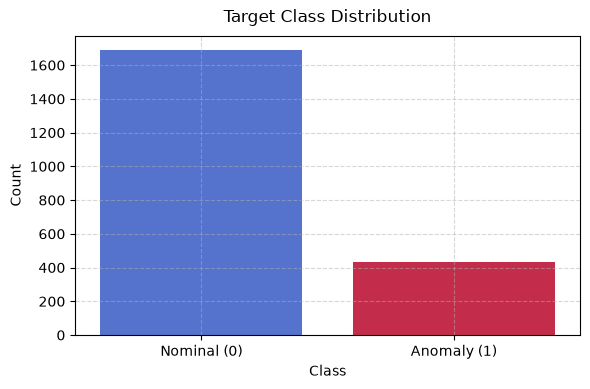

In [38]:
compute_column_statistics(df_dataset, 'anomaly', 'Target Class Distribution')
generate_property_plot(df_dataset, 'anomaly', 'Target Class Distribution', plot_type='count', labels=['Nominal (0)', 'Anomaly (1)'], xlabel="Class")

=== TRAIN / TEST SPLIT ANALYSIS ===
Total samples: 2123
Unique values: 2

Value Counts:
train
1    1594
0     529
Name: count, dtype: int64

Percentages:
train
1    75.082431
0    24.917569
Name: proportion, dtype: float64




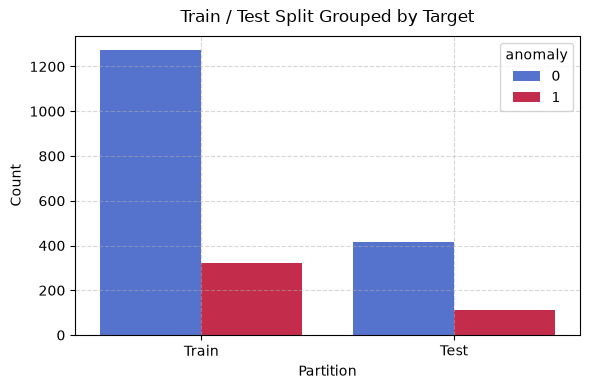

In [39]:
compute_column_statistics(df_dataset, 'train', 'Train / Test Split')
generate_property_plot(df_dataset, 'train', 'Train / Test Split Grouped by Target', plot_type='count', hue_col='anomaly', order=[1, 0], labels=['Train', 'Test'], xlabel="Partition")

=== TELEMETRY CHANNELS ANALYSIS ===
Total samples: 2123
Unique values: 9

Value Counts:
channel
CADC0873    593
CADC0872    546
CADC0888    252
CADC0892    211
CADC0874    194
CADC0884    158
CADC0894    144
CADC0890     14
CADC0886     11
Name: count, dtype: int64

Percentages:
channel
CADC0873    27.932171
CADC0872    25.718323
CADC0888    11.869995
CADC0892     9.938766
CADC0874     9.138012
CADC0884     7.442299
CADC0894     6.782854
CADC0890     0.659444
CADC0886     0.518135
Name: proportion, dtype: float64




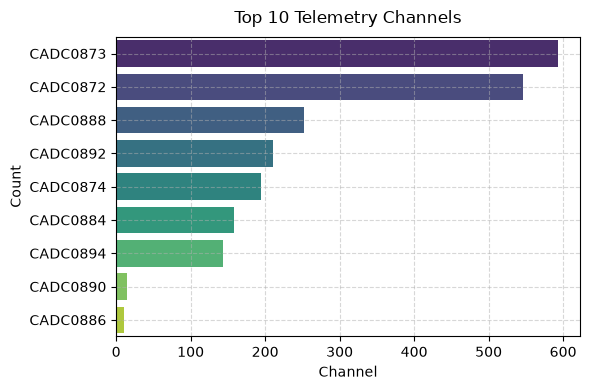

In [40]:
compute_column_statistics(df_dataset, 'channel', 'Telemetry Channels')
generate_property_plot(df_dataset, 'channel', 'Top 10 Telemetry Channels', plot_type='bar_horizontal')

## 4. Data Visualization
Time-series visual inspection and contextual subset retrieval.

In [53]:
def plot_telemetry_signal(df, column, target_col='anomaly', start=0, end=500, highlight_anomalies=False):
    if column not in df.columns:
        print(f"Error: Column '{column}' not found.")
        return
    if highlight_anomalies and target_col not in df.columns:
        print(f"Error: Target column '{target_col}' required for highlighting anomalies not found.")
        return

    sub_df = df.iloc[start:end].copy()
    plt.figure(figsize=(12, 4))
    
    plt.plot(range(start, end), sub_df[column].values, color='royalblue', linewidth=1.5, label='Telemetry Signal')
    
    if highlight_anomalies:
        anomaly_mask = (sub_df[target_col] == 1).values
        anomaly_indices = np.where(anomaly_mask)[0] + start
        if len(anomaly_indices) > 0:
            plt.scatter(anomaly_indices, df[column].iloc[anomaly_indices].values, color='crimson', s=30, zorder=3, label='Labeled Anomaly')
        plt.title(f"Telemetry Window with Highlighted Anomalies (Indices {start} to {end})", fontsize=14, pad=15)
        plt.legend(loc='upper right')
    else:
        plt.title(f"Raw Telemetry Signal: {column} (Indices {start} to {end})", fontsize=14, pad=15)
        
    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("Measured Value", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    if highlight_anomalies:
        print(f"Window Statistics for indices {start}-{end}:")
        print(sub_df[target_col].value_counts())

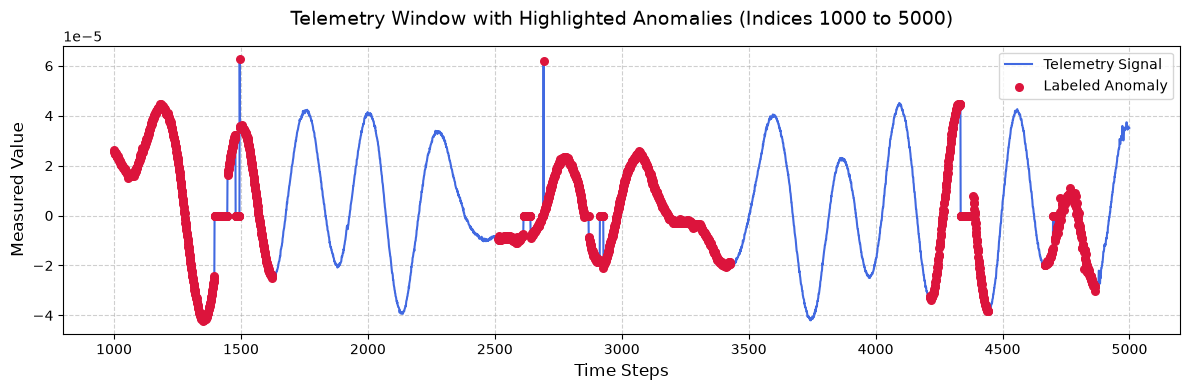

Window Statistics for indices 1000-5000:
anomaly
0    2031
1    1969
Name: count, dtype: int64


In [57]:
plot_telemetry_signal(df_segments, 'value', start=1000, end=5000, highlight_anomalies=True)